In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/energy_capstone.db')

# pull the joined dataset from notebook 1
df = pd.read_sql("""
    SELECT 
        e.year,
        ROUND(f.avg_crude_price, 2) as oil_price,
        ROUND(e.renewables_share_energy, 2) as world_renewables_pct,
        ROUND(e.solar_share_energy, 2) as solar_pct,
        ROUND(e.wind_share_energy, 2) as wind_pct
    FROM energy e
    JOIN fuel_prices f ON e.year = f.year
    WHERE e.country = 'World'
        AND e.year >= 1970
    ORDER BY e.year
""", conn)

df.head()

,year,oil_price,world_renewables_pct,solar_pct,wind_pct
0,1970,1.21,5.89,0.0,0.0
1,1971,1.69,5.93,0.0,0.0
2,1972,1.82,5.89,0.0,0.0
3,1973,2.81,5.65,0.0,0.0
4,1974,10.97,6.17,0.0,0.0


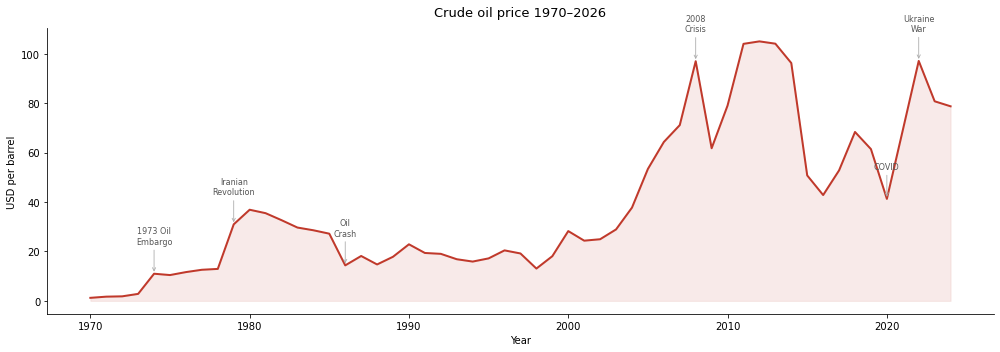

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['year'], df['oil_price'], color='#c0392b', linewidth=2)
ax.fill_between(df['year'], df['oil_price'], alpha=0.1, color='#c0392b')

# marking the events that caused the biggest moves
events = {
    1974: '1973 Oil\nEmbargo',
    1979: 'Iranian\nRevolution',
    1986: 'Oil\nCrash',
    2008: '2008\nCrisis',
    2020: 'COVID',
    2022: 'Ukraine\nWar'
}

for year, label in events.items():
    price = df.loc[df['year'] == year, 'oil_price'].values[0]
    ax.annotate(label, xy=(year, price), xytext=(year, price + 12),
                fontsize=8, ha='center', color='#555',
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.set_title('Crude oil price 1970–2026', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('USD per barrel')
sns.despine()
plt.tight_layout()
plt.savefig('../data/oil_price_timeline.png', dpi=150)
plt.show()

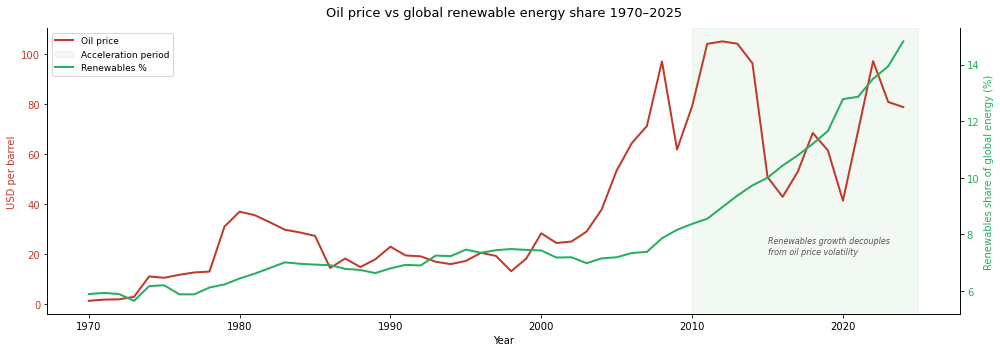

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# oil price on the left axis
ax1.plot(df['year'], df['oil_price'], color='#c0392b', linewidth=2, label='Oil price')
ax1.set_xlabel('Year')
ax1.set_ylabel('USD per barrel', color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')

# renewables share on the right axis
ax2 = ax1.twinx()
ax2.plot(df['year'], df['world_renewables_pct'], color='#27ae60', linewidth=2, label='Renewables %')
ax2.set_ylabel('Renewables share of global energy (%)', color='#27ae60')
ax2.tick_params(axis='y', labelcolor='#27ae60')

# shade the post-2010 period where growth really accelerates
ax1.axvspan(2010, 2025, alpha=0.05, color='green', label='Acceleration period')

# call out the decoupling — position adjusted to sit in the shaded region
ax1.annotate('Renewables growth decouples\nfrom oil price volatility',
             xy=(2015, 20), fontsize=8, color='#555', style='italic')

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Oil price vs global renewable energy share 1970–2025', fontsize=13, pad=12)
sns.despine(right=False)
plt.tight_layout()
plt.savefig('../data/dual_axis_chart.png', dpi=150)
plt.show()

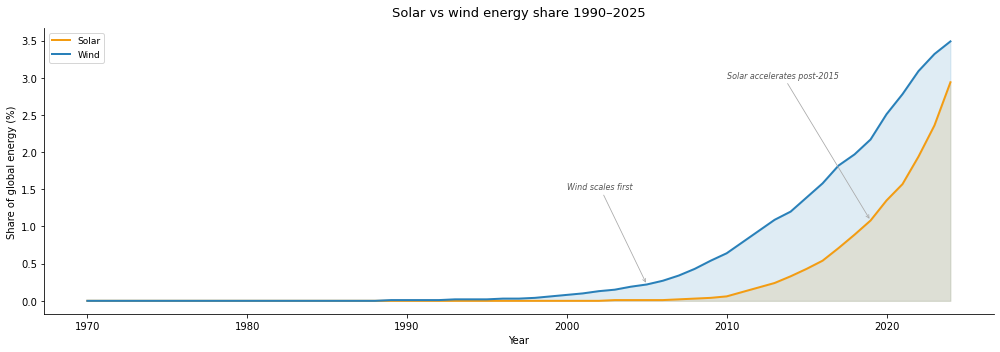

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

# drop rows where solar/wind data is missing — both were near zero pre-1990
df_sw = df.dropna(subset=['solar_pct', 'wind_pct'])

ax.plot(df_sw['year'], df_sw['solar_pct'], color='#f39c12', linewidth=2, label='Solar')
ax.plot(df_sw['year'], df_sw['wind_pct'], color='#2980b9', linewidth=2, label='Wind')
ax.fill_between(df_sw['year'], df_sw['solar_pct'], alpha=0.15, color='#f39c12')
ax.fill_between(df_sw['year'], df_sw['wind_pct'], alpha=0.15, color='#2980b9')

# wind took off first, solar overtook it recently
ax.annotate('Wind scales first', xy=(2005, df_sw.loc[df_sw['year']==2005, 'wind_pct'].values[0]),
            xytext=(2000, 1.5), fontsize=8, color='#555', style='italic',
            arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.annotate('Solar accelerates post-2015', xy=(2019, df_sw.loc[df_sw['year']==2019, 'solar_pct'].values[0]),
            xytext=(2010, 3), fontsize=8, color='#555', style='italic',
            arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.set_title('Solar vs wind energy share 1990–2025', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Share of global energy (%)')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../data/solar_wind_chart.png', dpi=150)
plt.show()

In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/energy_capstone.db')

# recreate df_connection — was built in notebook 1
df_connection = pd.read_sql("""
    SELECT 
        e.year,
        ROUND(f.avg_crude_price, 2) as oil_price,
        ROUND(e.renewables_share_energy, 2) as world_renewables_pct,
        ROUND(e.solar_share_energy, 2) as solar_pct,
        ROUND(e.wind_share_energy, 2) as wind_pct
    FROM energy e
    JOIN fuel_prices f ON e.year = f.year
    WHERE e.country = 'World'
        AND e.year >= 1970
    ORDER BY e.year
""", conn)

# save both CSVs for Tableau
df_connection.to_csv('../data/oil_vs_renewables.csv', index=False)

df_countries = pd.read_sql("""
    SELECT 
        country,
        iso_code,
        year,
        ROUND(renewables_share_energy, 1) as renewables_pct,
        ROUND(fossil_share_energy, 1) as fossil_pct,
        ROUND(solar_share_energy, 2) as solar_pct,
        ROUND(wind_share_energy, 2) as wind_pct
    FROM energy
    WHERE iso_code IS NOT NULL
        AND LENGTH(iso_code) = 3
        AND year >= 1970
        AND renewables_share_energy IS NOT NULL
    ORDER BY country, year
""", conn)

df_countries.to_csv('../data/country_energy_transition.csv', index=False)

print("Saved. Ready for Tableau.")

Saved. Ready for Tableau.


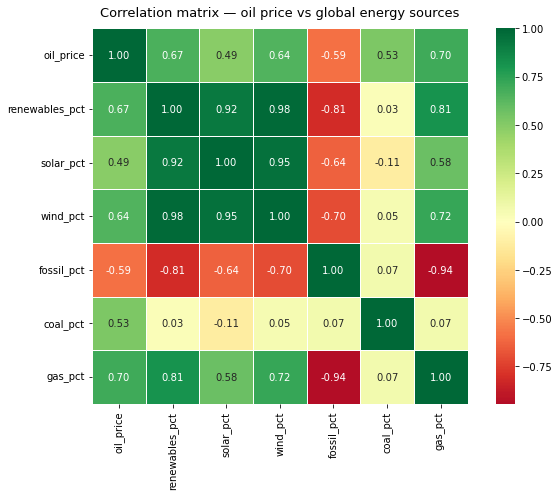

In [2]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/energy_capstone.db')

# pull the full dataset with all energy sources for correlation
df_corr = pd.read_sql("""
    SELECT 
        f.avg_crude_price as oil_price,
        e.renewables_share_energy as renewables_pct,
        e.solar_share_energy as solar_pct,
        e.wind_share_energy as wind_pct,
        e.fossil_share_energy as fossil_pct,
        e.coal_share_energy as coal_pct,
        e.gas_share_energy as gas_pct
    FROM energy e
    JOIN fuel_prices f ON e.year = f.year
    WHERE e.country = 'World'
        AND e.year >= 1970
""", conn)

# drop rows with missing values
df_corr = df_corr.dropna()

# calculate correlation matrix
corr = df_corr.corr()

# plot
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr, 
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation matrix — oil price vs global energy sources', 
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=150)
plt.show()